# HBN — Hierarchical Bipartite Network pour UTTT

## Concept : traiter la structure hiérarchique native d'UTTT

Le ResNet AlphaZero traite le plateau comme une **image 2D uniforme**.
Mais UTTT a une structure **hiérarchique naturelle** :
- Niveau 1 (local)  : 9 mini-grilles Tic-Tac-Toe 3×3 indépendantes
- Niveau 2 (global) : 1 méta-grille sur les résultats des mini-grilles
- Contrainte unique : le coup joué **force** la prochaine mini-grille

Un ResNet ne voit pas cette hiérarchie — il doit l'apprendre laborieusement.
**La HBN l'encode directement dans son architecture.**

---

## Architecture HBN

```
INPUT (9 sous-grilles)      NIVEAU LOCAL          NIVEAU GLOBAL

SG0 (6,3,3) ─┐             ┌────────────┐         ┌──────────────────┐
SG1 (6,3,3) ─┤─ MiniNet ──►│9 embeddings│──token──► Transformer       │
...          ─┤  (partagé) │(B,9,128)   │         │ Encoder (3 layers)│
SG8 (6,3,3) ─┘             └────────────┘         │ self-attn 9+CLS  │
                                                    └────────┬─────────┘
                                                             │
                                              ┌──────────────┴──────────────┐
                                              ▼                             ▼
                                       Policy Head                    Value Head
                                   9 tokens × 9 cases = 81         CLS token → tanh
```

### Encoding : 6 plans par sous-grille (symétrique — toujours du point de vue du joueur courant)

| Plan | Contenu |
|------|--------|
| 0 | Mes pièces dans cette sous-grille |
| 1 | Pièces adversaire dans cette sous-grille |
| 2 | Sous-grille gagnée par moi (broadcast) |
| 3 | Sous-grille gagnée par adversaire (broadcast) |
| 4 | Sous-grille active (broadcast) |
| 5 | Position de la sous-grille sur la méta-grille (normalisée) |

### Différences clés vs ResNet

| Aspect | ResNet AlphaZero | HBN |
|--------|-----------------|-----|
| Structure exploitée | Image 2D uniforme | Hiérarchie 2 niveaux |
| Inductive bias | Localité spatiale | Règles UTTT encodées |
| Paramètres | ~10M | ~3.5M |
| Backbone | Conv + ResBlocks | MiniNet + Transformer |
| Interaction locale/globale | Implicite | Explicite (attention) |
| Interprétabilité | Faible | Haute (attention maps) |
| Perspective | Absolue (joueur 1/2) | Symétrique (joueur courant) |


In [1]:
import os, math, numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from datasets import load_dataset
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

CFG = dict(
    local_in_channels = 6,
    local_hidden      = 64,
    embed_dim         = 128,
    nhead             = 4,
    num_tf_layers     = 3,
    policy_size       = 81,
    batch_size        = 512,
    lr                = 3e-4,
    weight_decay      = 1e-4,
    epochs            = 20,
    lambda_policy     = 1.5,
    min_visits        = 200,
    max_train_samples = 3_000_000,
    seed              = 42,
)
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print('Config OK')


Device : cuda
GPU    : Tesla P100-PCIE-16GB
Config OK


In [2]:
# ============================================================
# ENCODING HIERARCHIQUE — 6 plans par sous-grille
# ============================================================

def decode_state_string(s):
    n = len(s)
    assert n >= 81
    board      = np.array([int(c) for c in s[0:81]], dtype=np.int8)
    meta_board = np.array([int(c) for c in s[81:90]], dtype=np.int8) if n >= 90 else np.zeros(9, dtype=np.int8)
    active_idx = int(s[90]) if n >= 91 and 0 <= int(s[90]) <= 8 else -1
    cp = int(s[91]) if n >= 92 else None
    if cp not in (1, 2):
        cp = 1 if int((board == 1).sum()) == int((board == 2).sum()) else 2
    return board, meta_board, active_idx, cp


def state_to_hierarchical(s):
    """
    Encode en (9, 6, 3, 3) float32.
    Un tenseur (6, 3, 3) par sous-grille.
    Toujours du point de vue du joueur courant (encoding symetrique).
    """
    board, meta_board, active_idx, cp = decode_state_string(s)
    adv = 2 if cp == 1 else 1
    out = np.zeros((9, 6, 3, 3), dtype=np.float32)

    for sub in range(9):
        r_sub, c_sub = divmod(sub, 3)
        for cell in range(9):
            r_cell, c_cell = divmod(cell, 3)
            val = board[sub * 9 + cell]
            if val == cp:
                out[sub, 0, r_cell, c_cell] = 1.0
            elif val == adv:
                out[sub, 1, r_cell, c_cell] = 1.0
        if meta_board[sub] == cp:
            out[sub, 2] = 1.0
        if meta_board[sub] == adv:
            out[sub, 3] = 1.0
        if active_idx == -1 or active_idx == sub:
            out[sub, 4] = 1.0
        out[sub, 5] = (r_sub * 3 + c_sub) / 8.0

    return out


def compute_value_target(row):
    w, l, v = row['num_wins'], row['num_losses'], row['num_visits']
    return float(w - l) / float(v) if v > 0 else 0.0


def compute_policy_target(actions, policy_size=81):
    pi = np.zeros(policy_size, dtype=np.float32)
    if not actions:
        return pi
    for act in actions:
        v_a = act['num_wins'] + act['num_losses'] + act['num_draws']
        pi[act['index']] = float(act['num_wins'] - act['num_losses']) / v_a if v_a > 0 else 0.0
    mask = pi != 0
    if mask.sum() > 0:
        ev = np.exp(pi[mask] - pi[mask].max())
        pi[mask] = ev / ev.sum()
    return pi


# Test rapide
raw = load_dataset('markstanl/u3t', trust_remote_code=True)
sample = raw['train'][0]
h = state_to_hierarchical(sample['state'])
print(f'Shape hierarchique : {h.shape}  (9 sous-grilles x 6 plans x 3x3)')
print(f'Value target       : {compute_value_target(sample):.4f}')
print(f'State length       : {len(sample["state"])}')


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'markstanl/u3t' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

data/full_dataset/train.parquet:   0%|          | 0.00/883M [00:00<?, ?B/s]

data/full_dataset/test.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

data/full_dataset/validation.parquet:   0%|          | 0.00/126M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5601458 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1600367 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/800165 [00:00<?, ? examples/s]

Shape hierarchique : (9, 6, 3, 3)  (9 sous-grilles x 6 plans x 3x3)
Value target       : 0.1072
State length       : 93


In [3]:
class UTTTHierarchicalDataset(Dataset):
    def __init__(self, hf_split, min_visits=200, max_samples=None, seed=42):
        filtered = hf_split.filter(
            lambda x: x['num_visits'] >= min_visits,
            num_proc=4, desc='Filtrage'
        )
        print(f'  Apres filtrage : {len(filtered):,}')
        if max_samples and len(filtered) > max_samples:
            idx = np.random.default_rng(seed).choice(len(filtered), size=max_samples, replace=False)
            filtered = filtered.select(idx)
            print(f'  Sous-echantillonne : {len(filtered):,}')
        self.data = filtered

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        x  = torch.from_numpy(state_to_hierarchical(row['state']))
        z  = torch.tensor(compute_value_target(row), dtype=torch.float32)
        pi = torch.from_numpy(compute_policy_target(row['actions']))
        return x, z, pi


print('\n[TRAIN]')
train_ds = UTTTHierarchicalDataset(raw['train'],CFG['min_visits'], max_samples=CFG["max_train_samples"])
print('\n[VALIDATION]')
val_ds = UTTTHierarchicalDataset(raw['validation'],CFG['min_visits'])
print('\n[TEST]')
test_ds = UTTTHierarchicalDataset(raw['test'],CFG['min_visits'])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size']*2, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size']*2, shuffle=False, num_workers=0, pin_memory=True)
print(f'\nBatches train={len(train_loader):,}  val={len(val_loader):,}  test={len(test_loader):,}')



[TRAIN]


Filtrage (num_proc=4):   0%|          | 0/5601458 [00:00<?, ? examples/s]

  Apres filtrage : 5,601,458
  Sous-echantillonne : 3,000,000

[VALIDATION]


Filtrage (num_proc=4):   0%|          | 0/800165 [00:00<?, ? examples/s]

  Apres filtrage : 800,165

[TEST]


Filtrage (num_proc=4):   0%|          | 0/1600367 [00:00<?, ? examples/s]

  Apres filtrage : 1,600,367

Batches train=5,860  val=782  test=1,563


In [4]:
# ============================================================
# ARCHITECTURE HBN
# ============================================================

class MiniNet(nn.Module):
    """
    Encodeur local PARTAGE pour une sous-grille 3x3.
    Input  : (B, 6, 3, 3)
    Output : (B, embed_dim)

    2 blocs convolutifs residuels + GlobalAvgPool.
    Partage les poids entre toutes les 9 sous-grilles
    -> inductive bias fort : les sous-grilles sont interchangeables.
    """
    def __init__(self, in_ch=6, hidden=64, embed_dim=128):
        super().__init__()
        self.stem  = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden), nn.GELU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(hidden, embed_dim, 3, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim), nn.GELU(),
            nn.Conv2d(embed_dim, embed_dim, 3, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim)
        )
        self.up = nn.Conv2d(hidden, embed_dim, 1, bias=False)

    def forward(self, x):
        x = self.stem(x)
        x = F.gelu(self.block1(x) + x)
        x = F.gelu(self.block2(x) + self.up(x))
        return x.mean(dim=[-2, -1])


class HBNet(nn.Module):
    """
    Hierarchical Bipartite Network pour UTTT.

    Flux complet :
      1. MiniNet (partage) encode chaque sous-grille -> 9 tokens (B, 9, embed_dim)
      2. Positional embedding appris pour les 9 positions de sous-grille
      3. Token [CLS] concatene -> sequence (B, 10, embed_dim)
      4. Transformer Encoder (self-attention complete entre les 10 tokens)
         = chaque sous-grille "voit" toutes les autres + le contexte global [CLS]
      5. Policy Head : 9 tokens locaux -> 9 logits chacun = 81 logits totaux
      6. Value Head  : token [CLS] -> MLP -> tanh

    Pourquoi le Transformer est ideal ici :
      - L'attention encode les dependances directes entre sous-grilles
        (ex: "si sous-grille 4 est gagnee, sous-grille 4 de la meta est decisive")
      - Pas de biais de localite : toute interaction sous-grille i <-> j est traitee
        avec le meme cout, contrairement a une conv qui favorise les voisins
      - La regle de contrainte (coup -> prochaine sous-grille) est encodee
        dans le plan 4 (active) et visible par l'attention
    """
    def __init__(self, local_in=6, local_hidden=64, embed_dim=128,
                 nhead=4, num_tf_layers=3, policy_size=81):
        super().__init__()
        self.embed_dim = embed_dim

        # Niveau local
        self.mini_net  = MiniNet(local_in, local_hidden, embed_dim)
        self.pos_emb   = nn.Embedding(9, embed_dim)

        # Token CLS global
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        # Transformer global (Pre-LN plus stable a l'entrainement)
        tf_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(tf_layer, num_layers=num_tf_layers)

        # Policy head : par token local -> 9 logits
        self.policy_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, 9)
        )

        # Value head : CLS token -> scalar
        self.value_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.xavier_uniform_(m.weight)
                if hasattr(m, 'bias') and m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        """x : (B, 9, 6, 3, 3)"""
        B = x.size(0)

        # 1. Encoder local partage
        local_embs = self.mini_net(x.view(B * 9, 6, 3, 3))  # (B*9, embed_dim)
        local_embs = local_embs.view(B, 9, self.embed_dim)   # (B, 9, embed_dim)

        # 2. Positional embedding
        pos = torch.arange(9, device=x.device).unsqueeze(0)
        tokens = local_embs + self.pos_emb(pos)              # (B, 9, embed_dim)

        # 3. Ajouter CLS
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)             # (B, 10, embed_dim)

        # 4. Transformer global
        tokens = self.transformer(tokens)                    # (B, 10, embed_dim)
        cls_out = tokens[:, 0, :]                            # (B, embed_dim)
        sub_out = tokens[:, 1:, :]                           # (B, 9, embed_dim)

        # 5. Policy
        logits = self.policy_head(sub_out).view(B, -1)       # (B, 81)
        policy = F.log_softmax(logits, dim=1)

        # 6. Value
        value  = torch.tanh(self.value_head(cls_out)).squeeze(-1)  # (B,)

        return policy, value


# Instanciation
model = HBNet(
    local_in     = CFG['local_in_channels'],
    local_hidden = CFG['local_hidden'],
    embed_dim    = CFG['embed_dim'],
    nhead        = CFG['nhead'],
    num_tf_layers= CFG['num_tf_layers'],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parametres : {total_params:,}  (~{total_params/1e6:.1f}M)')

dummy = torch.randn(4, 9, 6, 3, 3).to(DEVICE)
with torch.no_grad():
    pol, val = model(dummy)
print(f'Policy : {pol.shape}  Value : {val.shape}')


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Parametres : 921,226  (~0.9M)
Policy : torch.Size([4, 81])  Value : torch.Size([4])


In [5]:
def compute_loss(pol_lp, val_pred, z, pi, lam=1.5):
    val_loss = F.mse_loss(val_pred, z)
    has_legal = pi.sum(dim=1) > 0
    if has_legal.sum() > 0:
        pol_loss = F.kl_div(pol_lp[has_legal], pi[has_legal],
                            reduction='batchmean', log_target=False)
    else:
        pol_loss = torch.tensor(0.0, device=val_pred.device)
    return val_loss + lam * pol_loss, val_loss.item(), pol_loss.item()


optimizer = AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = OneCycleLR(
    optimizer,
    max_lr=CFG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CFG['epochs'],
    pct_start=0.05,
    anneal_strategy='cos'
)
print(f'AdamW lr={CFG["lr"]}  wd={CFG["weight_decay"]}')
print(f'OneCycleLR  epochs={CFG["epochs"]}')


AdamW lr=0.0003  wd=0.0001
OneCycleLR  epochs=20


In [6]:
def run_epoch(loader, model, optimizer=None, scheduler=None, lam=1.5, desc=''):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    tot = val_l = pol_l = nb = 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, z, pi in tqdm(loader, desc=desc, leave=False):
            x, z, pi = x.to(DEVICE), z.to(DEVICE), pi.to(DEVICE)
            p_lp, v = model(x)
            loss, vl, pl = compute_loss(p_lp, v, z, pi, lam)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler:
                    scheduler.step()
            tot += loss.item(); val_l += vl; pol_l += pl; nb += 1
    return tot/nb, val_l/nb, pol_l/nb


history = {k: [] for k in ['tr_tot','tr_val','tr_pol','va_tot','va_val','va_pol']}
best_val = float('inf')
CKPT = 'best_hbn.pth'

print('='*65)
print(' ENTRAINEMENT HBN')
print('='*65)

for ep in range(1, CFG['epochs']+1):
    tr = run_epoch(train_loader, model, optimizer, scheduler, CFG['lambda_policy'], f'E{ep:02d}/train')
    va = run_epoch(val_loader,   model, desc=f'E{ep:02d}/val  ')
    flag = ''
    if va[0] < best_val:
        best_val = va[0]; torch.save(model.state_dict(), CKPT); flag = ' *saved*'
    for k, v in zip(['tr_tot','tr_val','tr_pol','va_tot','va_val','va_pol'], list(tr)+list(va)):
        history[k].append(v)
    print(f'E{ep:02d}  Train {tr[0]:.4f} (v={tr[1]:.4f} p={tr[2]:.4f})  '
          f'Val {va[0]:.4f} (v={va[1]:.4f} p={va[2]:.4f}){flag}')

print(f'Meilleure val loss : {best_val:.4f}')


 ENTRAINEMENT HBN


E01/train:   0%|          | 0/5860 [00:00<?, ?it/s]

E01/val  :   0%|          | 0/782 [00:00<?, ?it/s]

E01  Train 1.8811 (v=0.1133 p=1.1785)  Val 0.3612 (v=0.1005 p=0.1739) *saved*


E02/train:   0%|          | 0/5860 [00:00<?, ?it/s]

...

E19/val  :   0%|          | 0/782 [00:00<?, ?it/s]

E19  Train 0.1992 (v=0.0546 p=0.0964)  Val 0.1931 (v=0.0511 p=0.0947) *saved*


E20/train:   0%|          | 0/5860 [00:00<?, ?it/s]

E20/val  :   0%|          | 0/782 [00:00<?, ?it/s]

E20  Train 0.1989 (v=0.0545 p=0.0962)  Val 0.1931 (v=0.0510 p=0.0947)
Meilleure val loss : 0.1931


In [7]:
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
te_tot, te_val, te_pol = run_epoch(test_loader, model, desc='Test')

print('\n' + '='*60)
print(' RESULTATS FINAUX')
print('='*60)
print(f'  Train : total={history["tr_tot"][-1]:.4f}  value={history["tr_val"][-1]:.4f}  policy={history["tr_pol"][-1]:.4f}')
print(f'  Val   : total={history["va_tot"][-1]:.4f}  value={history["va_val"][-1]:.4f}  policy={history["va_pol"][-1]:.4f}')
print(f'  Test  : total={te_tot:.4f}  value={te_val:.4f}  policy={te_pol:.4f}')
print(f'  (Meilleure val loss : {best_val:.4f})')


Test:   0%|          | 0/1563 [00:00<?, ?it/s]


 RESULTATS FINAUX
  Train : total=0.1989  value=0.0545  policy=0.0962
  Val   : total=0.1931  value=0.0510  policy=0.0947
  Test  : total=0.1917  value=0.0508  policy=0.0939
  (Meilleure val loss : 0.1931)


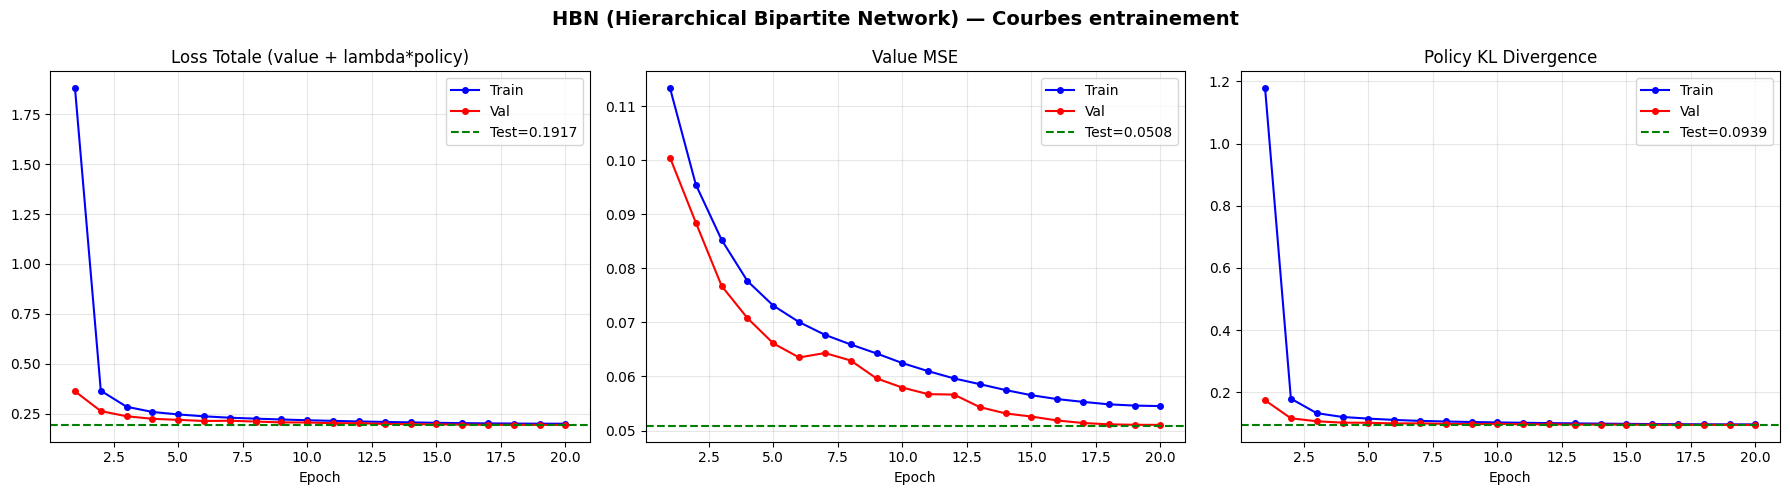

Courbes sauvegardees : hbn_curves.png


In [8]:
ep_r = range(1, len(history['tr_tot'])+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HBN (Hierarchical Bipartite Network) — Courbes entrainement', fontsize=14, fontweight='bold')

pairs = [
    ('tr_tot', 'va_tot', 'Loss Totale (value + lambda*policy)', te_tot),
    ('tr_val', 'va_val', 'Value MSE',                           te_val),
    ('tr_pol', 'va_pol', 'Policy KL Divergence',                te_pol),
]
for ax, (tk, vk, title, te) in zip(axes, pairs):
    ax.plot(ep_r, history[tk], 'b-o', ms=4, label='Train')
    ax.plot(ep_r, history[vk], 'r-o', ms=4, label='Val')
    ax.axhline(te, color='g', ls='--', label=f'Test={te:.4f}')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hbn_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Courbes sauvegardees : hbn_curves.png')


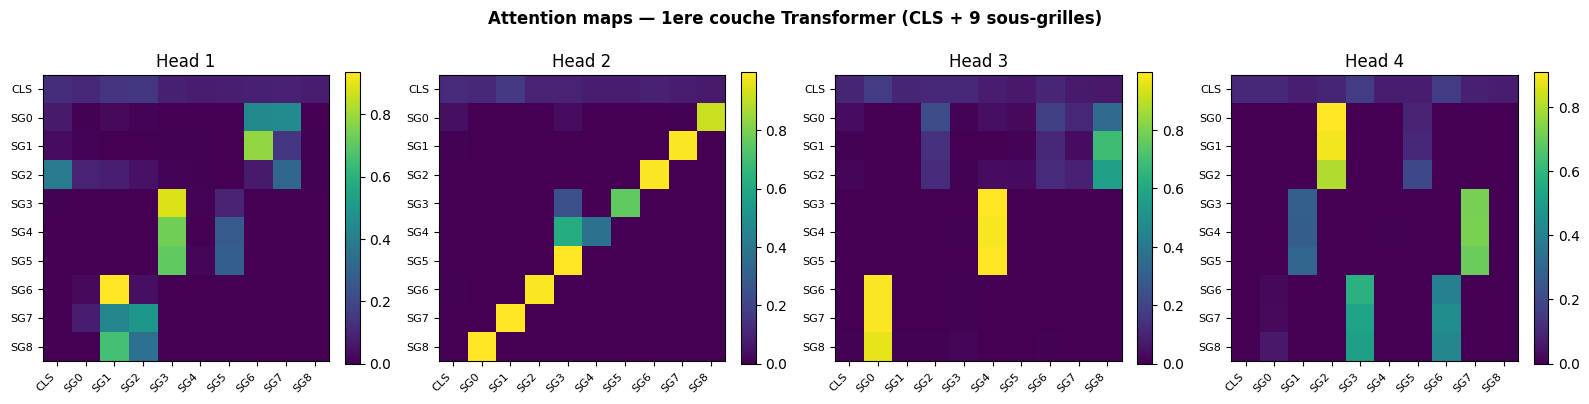

Attention maps sauvegardees : hbn_attention.png

Lecture : chaque cellule [i,j] = combien le token i "regarde" le token j.
La ligne CLS montre quelles sous-grilles sont les plus importantes pour la valeur.
Les lignes SG_i montrent quelles autres sous-grilles influencent la decision locale.


In [9]:
# ============================================================
# VISUALISATION DES ATTENTION MAPS
# Avantage unique de la HBN : interpretabilite via l'attention
# On voit exactement quelles sous-grilles le reseau met en relation
# ============================================================

def get_attention_maps(model, x_single):
    """
    Extrait les poids d'attention de la 1ere couche Transformer.
    x_single : (1, 9, 6, 3, 3)
    Retourne : (nhead, 10, 10)  (CLS + 9 sous-grilles)
    """
    model.eval()
    B = 1
    x_flat = x_single.view(9, 6, 3, 3).to(DEVICE)
    with torch.no_grad():
        local_embs = model.mini_net(x_flat).unsqueeze(0)
        pos = torch.arange(9, device=DEVICE).unsqueeze(0)
        tokens = local_embs + model.pos_emb(pos)
        cls    = model.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        layer  = model.transformer.layers[0]
        _, weights = layer.self_attn(
            tokens, tokens, tokens,
            need_weights=True, average_attn_weights=False
        )
    return weights.squeeze(0).cpu().numpy()


sample_x, _, _ = train_ds[0]
attn = get_attention_maps(model, sample_x.unsqueeze(0))

labels = ['CLS'] + [f'SG{i}' for i in range(9)]
nhead  = attn.shape[0]
fig, axes = plt.subplots(1, nhead, figsize=(4*nhead, 4))
if nhead == 1: axes = [axes]
fig.suptitle('Attention maps — 1ere couche Transformer (CLS + 9 sous-grilles)',
             fontsize=12, fontweight='bold')

for h, ax in enumerate(axes):
    im = ax.imshow(attn[h], cmap='viridis', vmin=0)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f'Head {h+1}')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('hbn_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print('Attention maps sauvegardees : hbn_attention.png')
print()
print('Lecture : chaque cellule [i,j] = combien le token i "regarde" le token j.')
print('La ligne CLS montre quelles sous-grilles sont les plus importantes pour la valeur.')
print('Les lignes SG_i montrent quelles autres sous-grilles influencent la decision locale.')


Analyse predictions:   0%|          | 0/1563 [00:00<?, ?it/s]

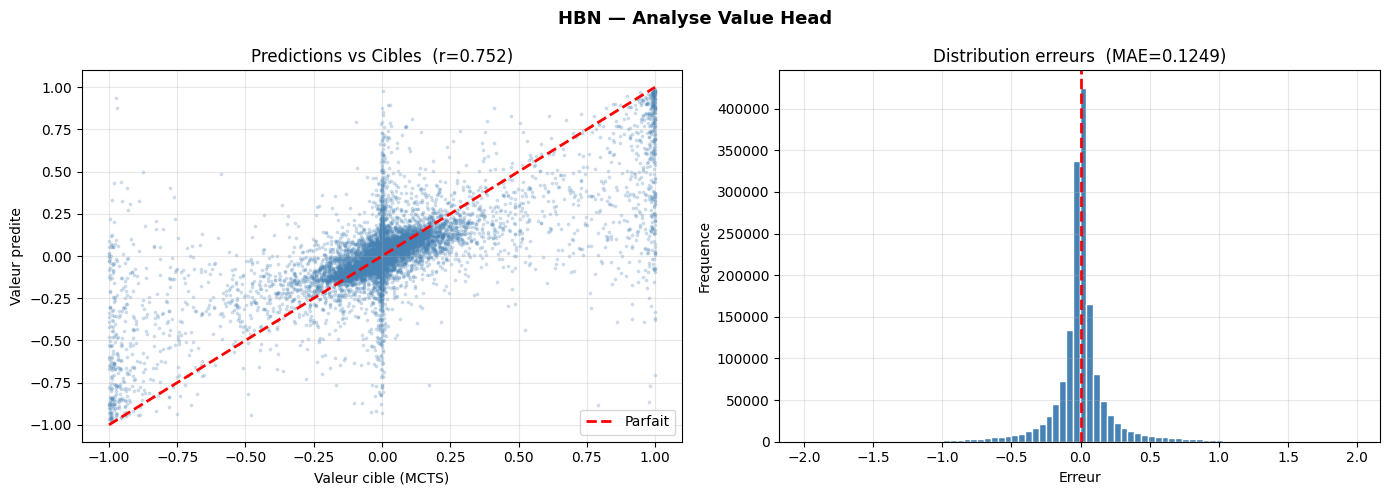


 TABLEAU RECAPITULATIF FINAL
  Split   |  Total Loss  | Value MSE | Policy KL
  Train   |      0.1989  |    0.0545 |    0.0962
  Val     |      0.1931  |    0.0510 |    0.0947
  Test    |      0.1917  |    0.0508 |    0.0939

  MSE test         : 0.0508
  MAE test         : 0.1249
  Correlation      : 0.7516
  Dir. accuracy    : 78.9%
  Parametres       : 921,226 (~0.9M)

  Architecture     : HBN (Hierarchical Bipartite Network)
  MiniNet local    : 64 filtres, 2 blocs residuels, partage entre 9 SG
  Transformer      : 3 couches x 4 tetes, embed=128
  Encoding         : symetrique (point de vue joueur courant)


In [10]:
# Analyse quantitative
model.eval()
z_true, z_pred = [], []
with torch.no_grad():
    for x, z, pi in tqdm(test_loader, desc='Analyse predictions'):
        _, v = model(x.to(DEVICE))
        z_true.extend(z.numpy()); z_pred.extend(v.cpu().numpy())

z_true, z_pred = np.array(z_true), np.array(z_pred)
mse  = np.mean((z_true - z_pred)**2)
mae  = np.mean(np.abs(z_true - z_pred))
corr = np.corrcoef(z_true, z_pred)[0, 1]
dacc = np.mean(np.sign(z_true) == np.sign(z_pred))

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HBN — Analyse Value Head', fontsize=13, fontweight='bold')

idx = np.random.choice(len(z_true), min(10000, len(z_true)), replace=False)
axes[0].scatter(z_true[idx], z_pred[idx], alpha=0.2, s=3, color='steelblue')
axes[0].plot([-1,1],[-1,1],'r--', lw=2, label='Parfait')
axes[0].set_xlabel('Valeur cible (MCTS)'); axes[0].set_ylabel('Valeur predite')
axes[0].set_title(f'Predictions vs Cibles  (r={corr:.3f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(z_true - z_pred, bins=80, color='steelblue', edgecolor='white', lw=0.3)
axes[1].axvline(0, color='red', ls='--', lw=2)
axes[1].set_xlabel('Erreur'); axes[1].set_ylabel('Frequence')
axes[1].set_title(f'Distribution erreurs  (MAE={mae:.4f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hbn_value_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print(' TABLEAU RECAPITULATIF FINAL')
print('='*60)
print(f'  Split   |  Total Loss  | Value MSE | Policy KL')
print(f'  Train   |  {history["tr_tot"][-1]:10.4f}  | {history["tr_val"][-1]:9.4f} | {history["tr_pol"][-1]:9.4f}')
print(f'  Val     |  {history["va_tot"][-1]:10.4f}  | {history["va_val"][-1]:9.4f} | {history["va_pol"][-1]:9.4f}')
print(f'  Test    |  {te_tot:10.4f}  | {te_val:9.4f} | {te_pol:9.4f}')
print(f'\n  MSE test         : {mse:.4f}')
print(f'  MAE test         : {mae:.4f}')
print(f'  Correlation      : {corr:.4f}')
print(f'  Dir. accuracy    : {dacc*100:.1f}%')
print(f'  Parametres       : {total_params:,} (~{total_params/1e6:.1f}M)')
print(f'\n  Architecture     : HBN (Hierarchical Bipartite Network)')
print(f'  MiniNet local    : {CFG["local_hidden"]} filtres, 2 blocs residuels, partage entre 9 SG')
print(f'  Transformer      : {CFG["num_tf_layers"]} couches x {CFG["nhead"]} tetes, embed={CFG["embed_dim"]}')
print(f'  Encoding         : symetrique (point de vue joueur courant)')
